# Edges vs. Coverage

Plots the per-node out-degree (x-axis, log scale) against `log(1 - coverage)` (y-axis), where coverage is the fraction of points covered. This is the inverse view of the degree-vs-coverage figure.

Reads the `edge_to_coverage_stats_{dataset}.csv` files written by `edge_to_coverage_analysis.py`. Columns:
`dataset, metric, method, dimensions, sources, total points, edges, mean points covered, median points covered, min points covered, max points covered`.

Note: the `... points covered` columns are **raw point counts**, not percentages. We convert each to a covered fraction by dividing by the `total points` column.

In [1]:
import glob
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
# Load every per-dataset stats file into one long DataFrame.
# Adjust the glob if the CSVs live elsewhere.
STATS_GLOB = "../edge_to_coverage/edge_to_coverage_stats_*.csv"

COVERAGE_COLS = ['mean points covered', 'median points covered',
                 'min points covered', 'max points covered']

files = sorted(glob.glob(STATS_GLOB))
if not files:
    raise FileNotFoundError(
        f"No files match {STATS_GLOB!r}. Run edge_to_coverage_analysis.py first, "
        "or point STATS_GLOB at the directory holding the CSVs."
    )

df = pd.concat([pd.read_csv(f) for f in files], ignore_index=True)
df['edges'] = df['edges'].astype(int)
df['total points'] = df['total points'].astype(float)
for col in COVERAGE_COLS:
    df[col] = df[col].astype(float)

# The CSV stores raw point counts, not percentages. Add covered-fraction
# columns (counts / total points) that the plots consume directly.
for col in COVERAGE_COLS:
    frac_col = col.replace('points covered', 'coverage frac')
    df[frac_col] = df[col] / df['total points']

print(f"Loaded {len(files)} file(s): {[os.path.basename(f) for f in files]}")
df['dataset'].unique()

Loaded 4 file(s): ['edge_to_coverage_stats_bigann.csv', 'edge_to_coverage_stats_facebook_sim_searchnet++.csv', 'edge_to_coverage_stats_spacev1b.csv', 'edge_to_coverage_stats_yandex_deep.csv']


<StringArray>
['bigann', 'facebook_sim_searchnet++', 'spacev1b', 'yandex_deep']
Length: 4, dtype: str

In [16]:
# Load the per-source curves for the largest-out-degree point in each dataset,
# written by extract_max_degree_curve.py (one CSV per adj-list). The default
# --out names files max_degree_curve_<adjlist-basename>.csv (e.g.
# max_degree_curve_adj-list-bigann.csv), so instead of parsing the filename we
# match each curve to a dataset by checking which dataset name in `df` appears
# in the filename. This is robust to the "adj-list-" prefix and optional
# "-<metric>" suffix.
MAXDEG_GLOB = "../edge_to_coverage/max_degree_curve_*.csv"

known_datasets = sorted(df['dataset'].unique(), key=len, reverse=True)  # longest first

max_deg_curves = {}  # dataset -> DataFrame(edges, points covered, coverage frac)
unmatched = []
for f in sorted(glob.glob(MAXDEG_GLOB)):
    base = os.path.basename(f)
    match = next((d for d in known_datasets if d in base), None)
    if match is None:
        unmatched.append(base)
        continue
    cdf = pd.read_csv(f).sort_values('edges')
    cdf['coverage frac'] = cdf['points covered'] / cdf['total points']
    # If two files map to the same dataset, keep the one with the larger degree.
    if match not in max_deg_curves or len(cdf) > len(max_deg_curves[match]):
        max_deg_curves[match] = cdf

if max_deg_curves:
    print("Max-degree curves matched to datasets:",
          {d: int(c['edges'].max()) for d, c in max_deg_curves.items()})
else:
    print(f"No max-degree curves matched at {MAXDEG_GLOB!r}. "
          "Run extract_max_degree_curve.py to generate them; the overlay will be skipped.")
if unmatched:
    print("WARNING: could not match to any dataset in df:", unmatched)

Max-degree curves matched to datasets: {'bigann': 647, 'facebook_sim_searchnet++': 61399, 'spacev1b': 2984, 'yandex_deep': 560}


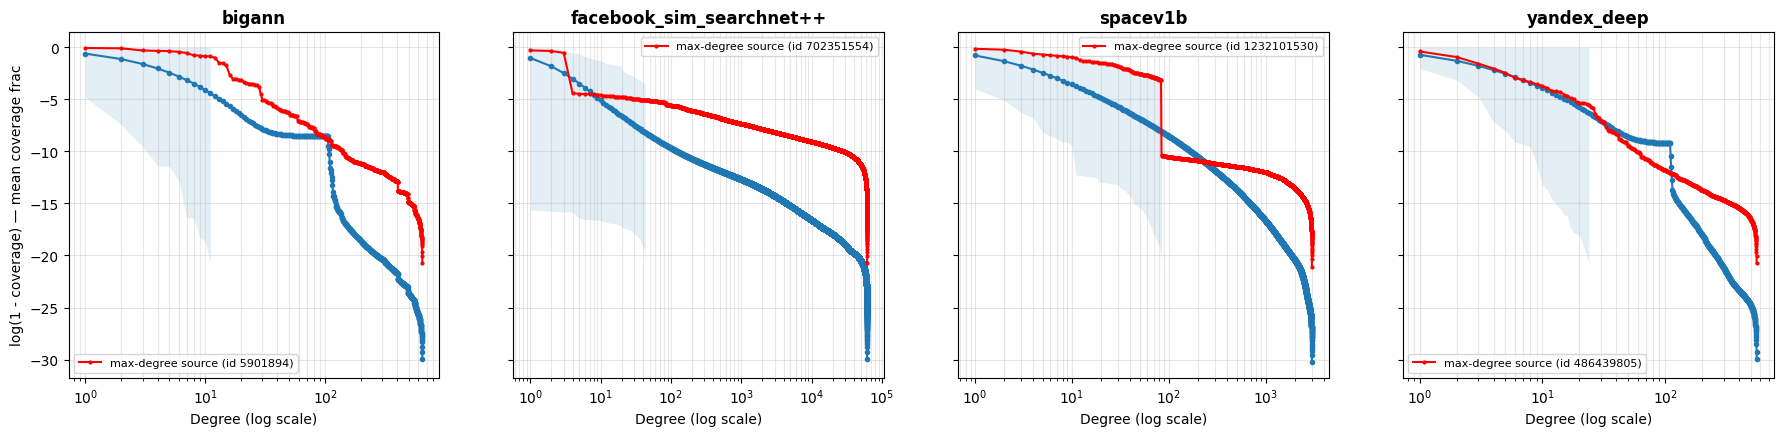

In [17]:
def plot_edges_vs_coverage(df, stat='mean coverage frac', show_band=True,
                           max_deg_curves=None, save_path=None):
    """One subplot per dataset: log(degree) (x) vs log(1 - coverage) (y).

    `edges` is the per-node out-degree, plotted on a log x-axis. `stat` names a
    covered-fraction column in [0, 1] (built in the load cell from the raw
    `... points covered` counts). We plot log(1 - coverage), i.e. the log of the
    remaining gap to full coverage; values near full coverage map to large-
    negative y. A separate curve is drawn per (metric, method) combination.

    If `max_deg_curves` is given (dataset -> per-source DataFrame from
    extract_max_degree_curve.py), the largest-out-degree source's own curve is
    overlaid in red, to expose whether drops in the aggregate come from a few
    high-degree outliers.
    """
    datasets = sorted(df['dataset'].unique())
    n_ds = len(datasets)

    # Floor the uncovered fraction so coverage == 1.0 doesn't blow up log().
    EPS = 1e-7

    def log_gap(cov_frac):
        # gap = np.clip(1.0 - cov_frac, EPS, None)
        return np.log(1.0 - cov_frac)

    fig, axes = plt.subplots(
        1, n_ds, figsize=(5.5 * n_ds, 4.5), squeeze=False, sharey=True
    )

    for c, dataset in enumerate(datasets):
        ax = axes[0, c]
        sub = df[df['dataset'] == dataset]

        for (metric, method), grp in sub.groupby(['metric', 'method']):
            grp = grp.sort_values('edges')
            line, = ax.plot(grp['edges'], log_gap(grp[stat]), marker='o', markersize=3)
            if show_band:
                # Note: min coverage -> upper gap, max coverage -> lower gap.
                ax.fill_between(
                    grp['edges'], log_gap(grp['min coverage frac']), log_gap(grp['max coverage frac']),
                    color=line.get_color(), alpha=0.12, linewidth=0,
                )

        # Overlay the single largest-out-degree source in red.
        if max_deg_curves and dataset in max_deg_curves:
            cdf = max_deg_curves[dataset]
            src_id = cdf['source_id'].iloc[0] if 'source_id' in cdf.columns else '?'
            ax.plot(cdf['edges'], log_gap(cdf['coverage frac']),
                    color='red', linewidth=1.5, marker='.', markersize=4,
                    label=f'max-degree source (id {src_id})', zorder=5)
            ax.legend(fontsize=8)

        ax.set_title(dataset, fontweight='bold')
        ax.set_xscale('log')
        ax.set_xlabel('Degree (log scale)')
        if c == 0:
            ax.set_ylabel(f'log(1 - coverage) — {stat}')
        ax.grid(True, alpha=0.3, which='both')

    # fig.tight_layout()
    if save_path:
        fig.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f"Saved -> {save_path}")
    plt.show()


plot_edges_vs_coverage(df, stat='mean coverage frac', show_band=True,
                       max_deg_curves=max_deg_curves)

Cliff steepness = most negative d[log(1-coverage)] / d[log edges] (more negative = sharper cliff):
  yandex_deep                  active-only=  -134.0 (near edges≈110)   all-clamped=  -135.1
  bigann                       active-only=   -96.6 (near edges≈105)   all-clamped=   -98.7
  spacev1b                     active-only=   -11.4 (near edges≈1342)   all-clamped=   -11.4
  facebook_sim_searchnet++     active-only=    -4.2 (near edges≈8691)   all-clamped=    -4.2

Edges to reach full coverage, by decile of fully-covered sources (out-degree distribution; NOT the cliff metric):
                                     bigann  facebook_sim_searchnet++  spacev1b  yandex_deep
percentile of fully-covered sources                                                         
10                                       53                       672       291           77
20                                       65                       908       354           96
30                                       75 

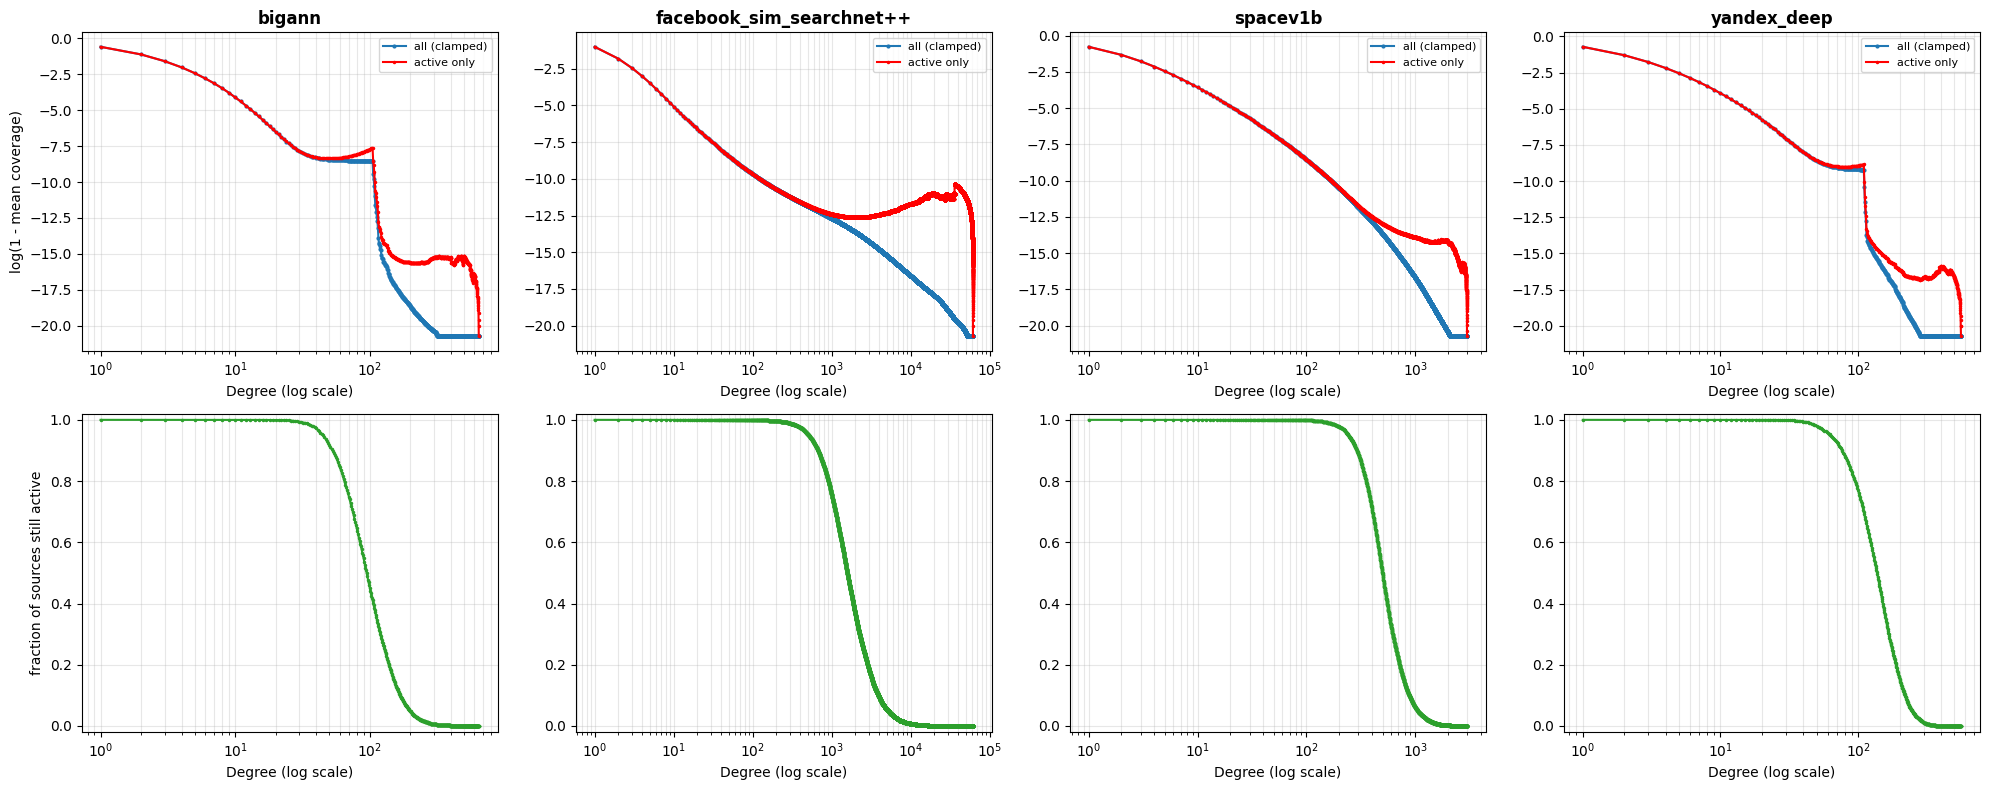

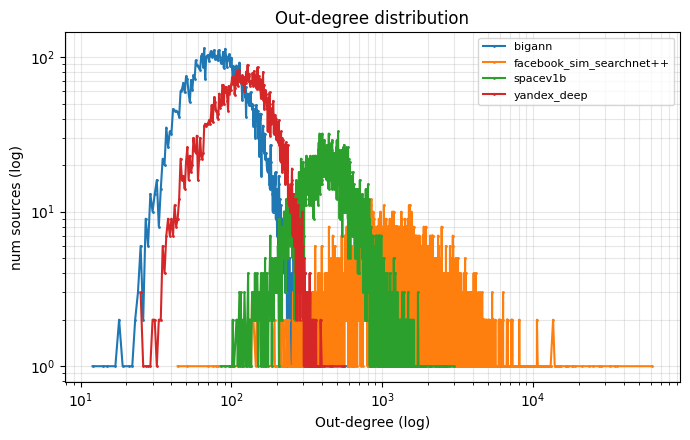

In [18]:
# --- Diagnose sharp drops: saturation cliff vs per-source geometric jump ---
# Load the diagnostics written by diagnose_coverage_drop.py (one _active.csv,
# one _degree_hist.csv, one _saturation_deciles.csv per dataset). Generate first:
#   python diagnose_coverage_drop.py \
#       --adj-list .../adj-list-bigann-euclidean.txt \
#       --computed .../bigann-euclidean-computed.txt \
#       --total-points 1000000000 --out ../edge_to_coverage/diag_bigann
DIAG_ACTIVE_GLOB = "../edge_to_coverage/diag_*_active.csv"
DIAG_HIST_GLOB   = "../edge_to_coverage/diag_*_degree_hist.csv"
DIAG_DEC_GLOB    = "../edge_to_coverage/diag_*_saturation_deciles.csv"

EPS = 1e-9
log_gap = lambda cf: np.log(np.clip(1.0 - np.asarray(cf, dtype=float), EPS, None))

def _match_dataset(path):
    base = os.path.basename(path)
    return next((d for d in known_datasets if d in base), None)

active_by_ds = {}
hist_by_ds = {}
dec_by_ds = {}
for f in sorted(glob.glob(DIAG_ACTIVE_GLOB)):
    d = _match_dataset(f)
    if d:
        active_by_ds[d] = pd.read_csv(f).sort_values('edges')
for f in sorted(glob.glob(DIAG_HIST_GLOB)):
    d = _match_dataset(f)
    if d:
        hist_by_ds[d] = pd.read_csv(f).sort_values('out_degree')
for f in sorted(glob.glob(DIAG_DEC_GLOB)):
    d = _match_dataset(f)
    if d:
        dec_by_ds[d] = pd.read_csv(f)

# Cliff steepness = the most negative slope of log(1 - coverage) vs log(edges).
# This is exactly what the eye reads off the plot, and it separates the cliff
# datasets from the smooth ones where the out-degree p90/p10 spread does NOT
# (all four datasets have a similar ~3x degree spread, so that metric is blind
# to the cliff). We measure it on the ACTIVE-ONLY curve: the "all (clamped)"
# curve slams into the EPS floor once the near-covered tail rounds to exactly
# 1.0, which inflates its apparent steepness; the active-only curve excludes
# saturated sources and reflects the true remaining-gap trajectory.
def cliff_steepness(a, col, min_frac_active=0.01):
    # Restrict to where a meaningful fraction of sources is still active. The
    # last 1-few active sources jumping to full coverage over a tiny log(edge)
    # step near max degree produces a huge spurious slope that is the tail, not
    # the cliff; the frac_active floor removes it.
    e = a['edges'].values.astype(float)
    y = log_gap(a[col].values)
    fa = a['frac_active'].values if 'frac_active' in a.columns else np.ones_like(e)
    m = np.isfinite(y) & (e > 0) & (fa >= min_frac_active)
    e, y = e[m], y[m]
    if len(e) < 3:
        return np.nan, np.nan
    slope = np.diff(y) / np.diff(np.log(e))
    i = int(np.nanargmin(slope))          # steepest (most negative) segment
    return slope[i], e[i]

if active_by_ds:
    print("Cliff steepness = most negative d[log(1-coverage)] / d[log edges] "
          "(more negative = sharper cliff):")
    rows = []
    for ds in sorted(active_by_ds):
        s_act, e_act = cliff_steepness(active_by_ds[ds], 'mean cov frac (active only)')
        s_all, _     = cliff_steepness(active_by_ds[ds], 'mean cov frac (all, clamped)')
        rows.append((ds, s_act, e_act, s_all))
    for ds, s_act, e_act, s_all in sorted(rows, key=lambda r: r[1]):  # sharpest first
        print(f"  {ds:28s} active-only={s_act:8.1f} (near edges≈{e_act:.0f})"
              f"   all-clamped={s_all:8.1f}")

# Context: edge count by which each decile of fully-covered sources saturates.
# NOTE: this measures the out-degree distribution shape, which is similar across
# datasets and does NOT track the cliff — keep it for reference, not as the cliff
# metric (that's cliff_steepness above).
if dec_by_ds:
    pcol, ecol = 'percentile of fully-covered sources', 'edges to reach full coverage'
    dec_table = pd.DataFrame({
        ds: t.set_index(pcol)[ecol] for ds, t in sorted(dec_by_ds.items())
    })
    print("\nEdges to reach full coverage, by decile of fully-covered sources "
          "(out-degree distribution; NOT the cliff metric):")
    print(dec_table.to_string())

if not active_by_ds:
    print(f"No diagnostics found at {DIAG_ACTIVE_GLOB!r}. "
          "Run diagnose_coverage_drop.py to generate them.")
else:
    diag_datasets = sorted(active_by_ds)
    n = len(diag_datasets)

    fig, axes = plt.subplots(2, n, figsize=(5.0 * n, 8), squeeze=False)
    for c, ds in enumerate(diag_datasets):
        a = active_by_ds[ds]

        # Row 0: log(1 - coverage) — ALL (clamped) vs ACTIVE-ONLY sources.
        # If active-only diverges upward from all-clamped as sources saturate
        # (spacev1b, facebook), the still-active tail carries real uncovered
        # mass => smooth. If active-only tracks all into the floor (bigann,
        # yandex), the tail is already near-covered => sharp cliff.
        ax = axes[0, c]
        ax.plot(a['edges'], log_gap(a['mean cov frac (all, clamped)']),
                color='C0', marker='o', markersize=2, label='all (clamped)')
        ax.plot(a['edges'], log_gap(a['mean cov frac (active only)']),
                color='red', marker='.', markersize=3, label='active only')
        # ax.axhline(np.log(EPS), color='gray', ls=':', lw=1, label='EPS floor')
        ax.set_xscale('log')
        ax.set_title(ds, fontweight='bold')
        ax.set_xlabel('Degree (log scale)')
        if c == 0:
            ax.set_ylabel('log(1 - mean coverage)')
        ax.grid(True, alpha=0.3, which='both')
        ax.legend(fontsize=8)

        # Row 1: fraction of sources still active (out-degree > k) vs edges.
        ax2 = axes[1, c]
        ax2.plot(a['edges'], a['frac_active'], color='C2', marker='.', markersize=3)
        ax2.set_xscale('log')
        ax2.set_xlabel('Degree (log scale)')
        if c == 0:
            ax2.set_ylabel('fraction of sources still active')
        ax2.set_ylim(-0.02, 1.02)
        ax2.grid(True, alpha=0.3, which='both')

    fig.tight_layout()
    plt.show()

    # Out-degree distribution (log-log).
    if hist_by_ds:
        fig, ax = plt.subplots(figsize=(7, 4.5))
        for ds in sorted(hist_by_ds):
            h = hist_by_ds[ds]
            ax.plot(h['out_degree'], h['n_sources'], marker='.', markersize=2, label=ds)
        ax.set_xscale('log'); ax.set_yscale('log')
        ax.set_xlabel('Out-degree (log)'); ax.set_ylabel('num sources (log)')
        ax.set_title('Out-degree distribution')
        ax.grid(True, alpha=0.3, which='both'); ax.legend(fontsize=8)
        fig.tight_layout(); plt.show()

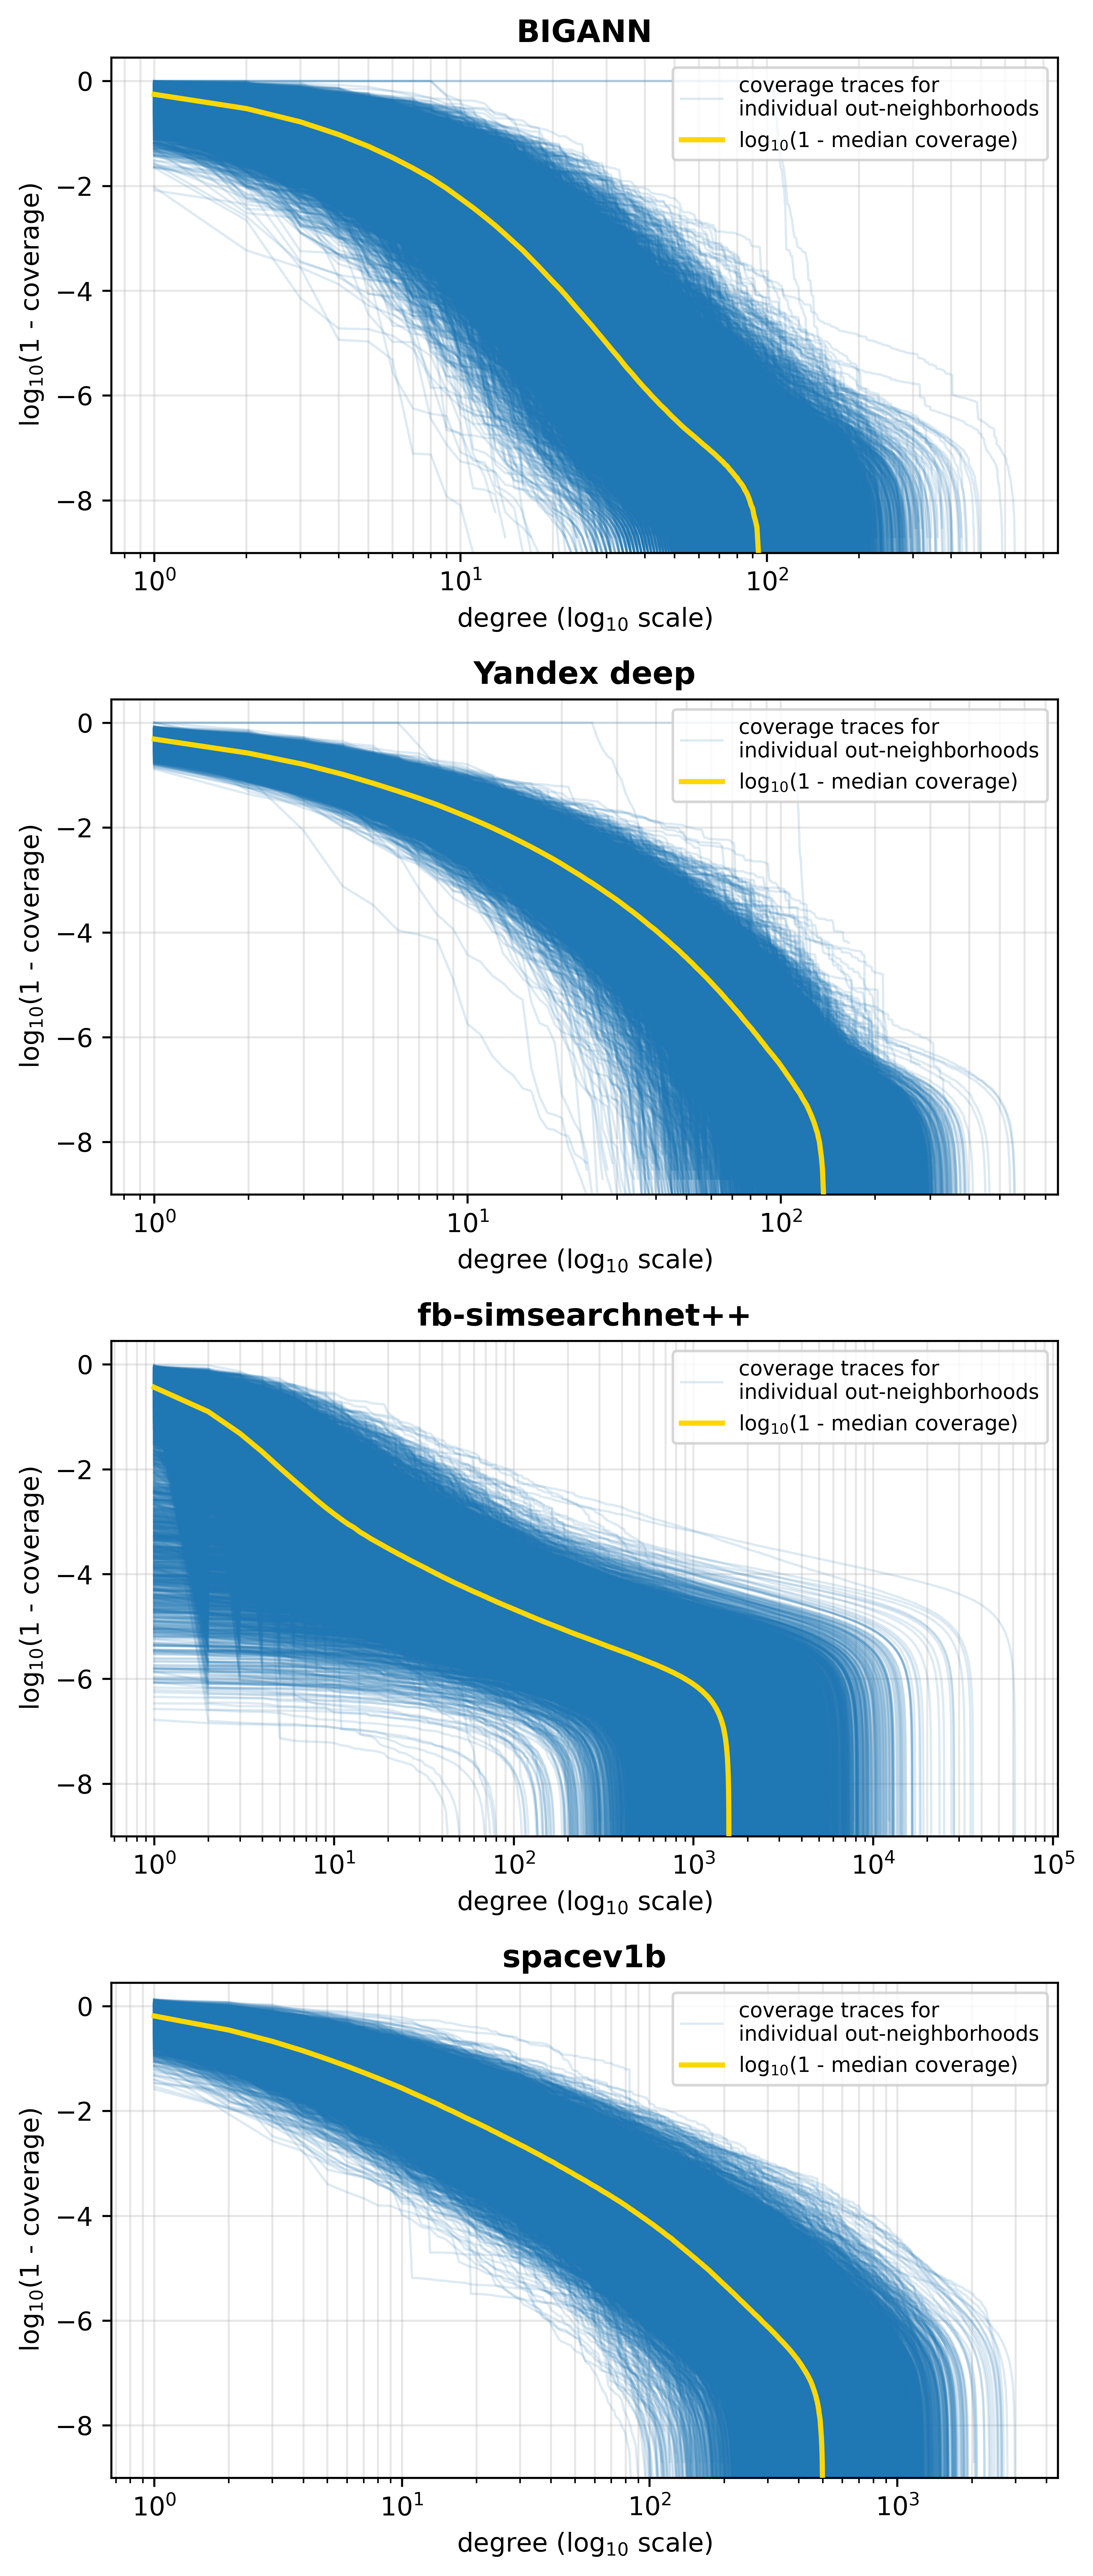

10000


In [12]:
# --- Per-source curves: log(1 - coverage) vs degree (log scale), one plot per dataset ---
# Reads the raw per-source adjacency lists (bare "[(neighbor, uncov_after_edge),
# ...]" lines, new post-edge convention) and draws one faint line per sampled
# source, plus the median curve overlaid. A column of n plots (one per dataset),
# all with degree on a log x-axis.
import ast, random
np.seterr(divide = 'ignore')

BUILT_GRAPHS = "../new_results/"
PER_SOURCE_FILES = {                 # dataset -> (adj-list path, total points)
    'BIGANN':      (f"{BUILT_GRAPHS}/adj-list-bigann.txt",      1_000_000_000),
    'Yandex deep': (f"{BUILT_GRAPHS}/adj-list-yandex_deep.txt", 1_000_000_000),
    'spacev1b': (f"{BUILT_GRAPHS}/adj-list-spacev1b-euclidean.txt", 1_000_000_000),
    'fb-simsearchnet++': (f"{BUILT_GRAPHS}/adj-list-facebook_sim_searchnet++.txt", 1_000_000_000),
}

# number of sources to subsample per dataset (variable)
m = 10_000       
SEED = 0         # for reproducible sampling
# No clipping: coverage == 1.0 gives log(0) = -inf, which matplotlib simply
# drops from the line (the curve runs off the bottom toward -inf).
ps_log_gap = lambda cf: np.log10(1.0 - np.asarray(cf, float)) 

def sample_source_curves(path, total_points, m, seed=0):
    with open(path) as f:
        lines = [ln for ln in f if ln.strip()]
    rng = random.Random(seed)
    picks = rng.sample(lines, min(m, len(lines)))
    curves = []
    for line in picks:
        nb = ast.literal_eval(line)
        if nb:
            uncov = np.array([u for (_n, u) in nb], dtype=np.float64)
            curves.append((total_points - uncov) / total_points)
    return curves


def clamped_matrix(curves):
    """(n_sources, max_deg) coverage matrix, each source clamped at its final
    coverage for edge counts beyond its degree (matches the aggregate CSV)."""
    max_deg = max(len(c) for c in curves)
    mat = np.empty((len(curves), max_deg))
    for i, cov in enumerate(curves):
        d = len(cov)
        mat[i, :d] = cov
        mat[i, d:] = cov[-1]        # clamp saturated sources at their final cov
    return mat

plt.rcParams.update({
        # 'font.size': 7, 'axes.titlesize': 8, 'axes.labelsize': 8,
        # 'xtick.labelsize': 6, 'ytick.labelsize': 6, 'legend.fontsize': 7,
        # 'lines.linewidth': 1.2, 'lines.markersize': 2,
        'figure.dpi': 600, 'savefig.dpi': 600,
    })

ps_datasets = sorted(PER_SOURCE_FILES)
n = len(ps_datasets)
# A column of n plots (one per dataset), degree on a log x-axis.
fig, axes = plt.subplots(n, 1, figsize=(6, 3.5 * n), squeeze=False, sharey=True)
for r, ds in enumerate(ps_datasets):
    ax = axes[r, 0]
    path, tot = PER_SOURCE_FILES[ds]
    curves = sample_source_curves(path, tot, m, seed=SEED)
    mat = clamped_matrix(curves)
    mean_cov = mat.mean(axis=0)
    median_cov = np.median(mat, axis=0)
    agg_edges = np.arange(1, mat.shape[1] + 1)

    # y-axis floor: the most-negative FINITE log(1-cov) among individual source
    # points (i.e. the smallest nonzero uncovered fraction seen). Below this the
    # mean/median dive toward -inf as sources saturate; clip the view there so
    # the plot stops where the real per-source lines do.
    finite_uncov = (1.0 - mat)[(1.0 - mat) > 0]
    y_floor = np.log10(finite_uncov.min()) if finite_uncov.size else -1.0

    for i, cov in enumerate(curves):
        edges = np.arange(1, len(cov) + 1)
        # Only label the first trace so the legend shows this entry once.
        label = 'coverage traces for \nindividual out-neighborhoods' if i == 0 else '_nolegend_'
        ax.plot(edges, ps_log_gap(cov), color='C0', alpha=0.15, linewidth=0.9, label=label)
    # Mean and median curves overlaid.
    # ax.plot(agg_edges, ps_log_gap(mean_cov), color='red', linewidth=2,
    #         label='log$_{10}$(1 - mean coverage)', zorder=5)
    ax.plot(agg_edges, ps_log_gap(median_cov), color='gold', linewidth=2,
            label='log$_{10}$(1 - median coverage)', zorder=6)
    ax.set_xscale('log')
    ax.set_title(f"{ds}", fontweight='bold')
    ax.set_xlabel('degree (log$_{10}$ scale)')
    ax.set_ylabel('log$_{10}$(1 - coverage)')
    ax.grid(True, alpha=0.3, which='both')
    ax.legend(fontsize=8, loc='upper right')
    # Clip the view so the mean/median don't dive toward -inf below the lines.
    ax.set_ylim(bottom=y_floor)
fig.tight_layout()
plt.show()
print(m)